# 04 - XAI / Topographic Analysis (stub)

**Status: stub wired to evaluation output (Phase 7).** Full SHAP channel attribution and `mne.viz.plot_topomap` scalp rendering (README §12) land in Phase 8 (`src/xai/`). This notebook demonstrates the handoff point: train a small checkpoint, run it through `src.evaluation.evaluate`, and inspect per-epoch predictions and per-channel signal statistics that Phase 8's SHAP wrapper will attribute over. Everything below actually executes against real (synthetic) data — nothing here is a mockup.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.synthetic import CHANNEL_NAMES
from src.evaluation.evaluate import evaluate_checkpoint
from src.training.train import run
from src.utils.config import AeroMindConfig, DataConfig, ModelConfig, TrainConfig, load_config
from src.utils.seed import set_seed

set_seed(42)

## Train a small checkpoint

A few epochs on a small synthetic cohort — enough to produce a real, loadable checkpoint for this notebook to evaluate, not a claim about model quality (see `results/synthetic_smoke_test.md` for the actual training smoke test).

In [2]:
config = AeroMindConfig(
    data=DataConfig(processed_dir='data/processed/_notebook_04_scratch', sequence_length=3),
    model=ModelConfig(name='aeromind_eegnet'),
    train=TrainConfig(protocol='subject_dependent', epochs=3, batch_size=8,
                       early_stop_patience=2, mixed_precision=False),
    output_dir='runs/_notebook_04_scratch',
)
summary = run(config, n_subjects=4, duration_s=90.0)
summary['workload_accuracy_mean'], summary['fatigue_accuracy_mean']

10:42:14 | INFO    | src.training.train | Device: cpu


10:42:14 | INFO    | src.training.train | No materialized dataset at data\processed\_notebook_04_scratch — generating 4 synthetic subjects in-memory


10:42:15 | INFO    | src.training.train | Loaded 356 epochs, class balance: {'workload': {0: 130, 1: 150, 2: 76}, 'fatigue': {0: 204, 1: 152}}


10:42:19 | INFO    | src.training.train | Run complete: {'protocol': 'subject_dependent', 'model': 'aeromind_eegnet', 'config_hash': '4e5d11c15872', 'n_folds': 1, 'n_folds_completed': 1, 'workload_accuracy_mean': 0.4, 'workload_accuracy_std': 0.0, 'fatigue_accuracy_mean': 0.5166666666666667, 'fatigue_accuracy_std': 0.0, 'workload_macro_f1_mean': 0.19047619047619047, 'workload_macro_f1_std': 0.0, 'fatigue_macro_f1_mean': 0.34065934065934067, 'fatigue_macro_f1_std': 0.0, 'workload_kappa_mean': 0.0, 'workload_kappa_std': 0.0, 'fatigue_kappa_mean': 0.0, 'fatigue_kappa_std': 0.0}


(0.4, 0.5166666666666667)

## Evaluate the checkpoint via `src.evaluation.evaluate`

This is the same code path `python -m src.evaluation.evaluate` runs from the command line — deterministic fold reconstruction from the saved config, checkpoint load, held-out test evaluation.

In [3]:
loaded_config = load_config('runs/_notebook_04_scratch/config.yaml')
result, meta = evaluate_checkpoint(
    loaded_config,
    'runs/_notebook_04_scratch/subject_dependent/best.ckpt',
    fold_name='subject_dependent',
    n_subjects=4,
    duration_s=90.0,
)
meta, result.workload_report.accuracy, result.fatigue_report.accuracy

10:42:19 | INFO    | src.training.train | No materialized dataset at data\processed\_notebook_04_scratch — generating 4 synthetic subjects in-memory


({'model': 'aeromind_eegnet',
  'protocol': 'subject_dependent',
  'fold': 'subject_dependent',
  'checkpoint': 'runs/_notebook_04_scratch/subject_dependent/best.ckpt',
  'n_test_sequences': 60,
  'config_hash': '4e5d11c15872'},
 0.4,
 0.5166666666666667)

## Confusion matrix (workload head)

The kind of per-class breakdown Phase 8's counter-factual probe will use to decide which predictions are worth explaining.

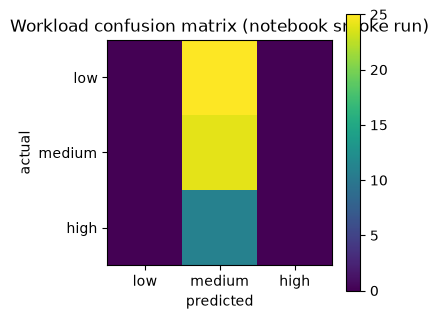

In [4]:
from src.data.synthetic import WORKLOAD_LABELS

cm = pd.DataFrame(result.workload_report.confusion, index=WORKLOAD_LABELS, columns=WORKLOAD_LABELS)
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(cm.values, cmap='viridis')
ax.set_xticks(range(3)); ax.set_xticklabels(WORKLOAD_LABELS)
ax.set_yticks(range(3)); ax.set_yticklabels(WORKLOAD_LABELS)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('Workload confusion matrix (notebook smoke run)')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## Where Phase 8 plugs in

`src/xai/shap_channel.py` will wrap `shap.GradientExplainer` around the trained model loaded above to get per-channel attributions for a given prediction; `src/xai/topomap.py` will render those attributions onto the `CHANNEL_NAMES` montage via `mne.viz.plot_topomap`; `src/xai/counter_factual.py` will attenuate frontal-theta on a held-out high-workload epoch (identifiable from the confusion matrix above) and check the prediction shifts toward lower workload. This notebook will be extended in place once those modules exist, rather than replaced.